# Spectral Rank Analysis at FK Aggregation

This notebook demonstrates the spectral rank analysis experiment that measures
information compression (rank collapse) at foreign-key aggregation steps in
HeteroSAGE graph neural networks.

**What this does:**
- Loads pre-computed rank analysis results from 3 RelBench tasks with contrasting CAMA effect sizes
- Demonstrates the core rank computation functions (SVD effective rank, variance-entropy proxy)
- Analyzes compression ratios across edge types and tasks
- Correlates compression severity with CAMA Cohen's d to test the rank-collapse hypothesis

**Key finding:** Rank collapse IS observed (mean compression ratio ~0.84), with Spearman rho=-0.5
between compression severity and CAMA Cohen's d, providing directional support for the hypothesis.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.15.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import math
import os
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import pearsonr, spearmanr

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-9b0386-rank-aware-moment-aggregation-diversity-/main/experiment_iter5_spectral_rank_a/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded data with {len(data['datasets'])} datasets")
for ds in data['datasets']:
    print(f"  {ds['dataset']}: {len(ds['examples'])} examples")
print(f"\nKey findings: {json.dumps(data['metadata']['key_findings'], indent=2)}")

Loaded data with 4 datasets
  rel-f1/driver-dnf: 3 examples
  rel-trial/study-adverse: 3 examples
  rel-stack/user-engagement: 3 examples
  cross_task_analysis: 3 examples

Key findings: {
  "rank_collapse_observed": true,
  "mean_compression_ratio": 0.842405239381871,
  "proxy_validates_svd": true,
  "mean_proxy_svd_spearman": 0.6294012247726517,
  "compression_correlates_with_benefit": false,
  "spearman_severity_vs_d": -0.5,
  "disconfirmation_triggered": false
}


## Configuration

Parameters controlling the analysis. The original experiment used these values
for training HeteroSAGE models on RelBench tasks.

In [5]:
# --- Config: tunable parameters ---
CHANNELS = 128          # embedding dimension (original: 128)
EPS = 1e-10             # numerical stability epsilon
SEED = 42               # random seed
NUM_SYNTHETIC_PARENTS = 20   # number of synthetic parent nodes for demo (original analysis: 1000)
MAX_CHILDREN = 50       # max children per parent for synthetic demo (original: 500)
MIN_CHILDREN = 2        # min children per parent

# Known CAMA Cohen's d values for each task
CAMA_COHENS_D = {
    "rel-f1/driver-dnf": 1.13,
    "rel-trial/study-adverse": -2.45,
    "rel-stack/user-engagement": 7.95,
}

np.random.seed(SEED)
print(f"Config: CHANNELS={CHANNELS}, NUM_SYNTHETIC_PARENTS={NUM_SYNTHETIC_PARENTS}, MAX_CHILDREN={MAX_CHILDREN}")

Config: CHANNELS=128, NUM_SYNTHETIC_PARENTS=20, MAX_CHILDREN=50


## Core Rank Computation Functions

These are the key analysis functions from the original experiment, adapted to use
NumPy instead of PyTorch for portability. They compute:

1. **SVD Effective Rank** (`erank`): Exponential of the Shannon entropy of normalized singular values
2. **Variance-Entropy Proxy**: A cheaper approximation using per-dimension variance entropy
3. **Compression Ratio**: Ratio of effective rank to maximum possible rank

In [6]:
def compute_svd_effective_rank(C: np.ndarray, eps: float = EPS) -> float:
    """SVD-based effective rank of child embedding matrix C [N, d].
    erank = exp(H(sigma)) where sigma are normalized singular values."""
    if C.shape[0] < 2:
        return 1.0
    try:
        s = np.linalg.svd(C.astype(np.float64), compute_uv=False)
    except Exception:
        return float('nan')
    s = s[s > eps]
    if len(s) == 0:
        return 0.0
    p = s / s.sum()
    H = -(p * np.log(p)).sum()
    return math.exp(H)


def compute_variance_entropy_proxy(C: np.ndarray, d: int, eps: float = EPS) -> float:
    """Variance-entropy proxy: H(var) / log(d), normalized to [0, 1]."""
    if C.shape[0] < 2:
        return 1.0 / max(d, 1)
    var = np.var(C, axis=0)
    var_sum = var.sum()
    if var_sum < eps:
        return 1.0 / max(d, 1)
    p = var / var_sum
    p = np.clip(p, eps, None)
    H = -(p * np.log(p)).sum()
    log_d = math.log(max(d, 2))
    return float(H / log_d)


def compute_compression_ratio(erank: float, N: int, d: int) -> float:
    """Ratio of effective rank to maximum possible rank = min(N, d)."""
    max_rank = min(N, d)
    if max_rank == 0:
        return float('nan')
    return erank / max_rank


print("Rank computation functions defined.")

Rank computation functions defined.


## Synthetic Rank Computation Demo

Demonstrate rank computation on synthetic child embeddings to show how
SVD effective rank and the variance-entropy proxy behave under different
conditions (varying cardinality and embedding diversity).

In [7]:
# Generate synthetic parent-child aggregation scenarios
results_synthetic = []
for i in range(NUM_SYNTHETIC_PARENTS):
    N = np.random.randint(MIN_CHILDREN, MAX_CHILDREN + 1)
    # Vary the effective dimensionality: some parents have near-identical children (collapse)
    collapse_factor = np.random.uniform(0.01, 1.0)
    # Create children: base vector + scaled random perturbations
    base = np.random.randn(1, CHANNELS)
    noise = np.random.randn(N, CHANNELS) * collapse_factor
    C = base + noise  # shape [N, CHANNELS]

    svd_rank = compute_svd_effective_rank(C)
    proxy = compute_variance_entropy_proxy(C, CHANNELS)
    compression = compute_compression_ratio(svd_rank, N, CHANNELS)

    results_synthetic.append({
        'parent_id': i,
        'cardinality': N,
        'collapse_factor': collapse_factor,
        'svd_effective_rank': svd_rank,
        'proxy_rank': proxy,
        'compression_ratio': compression,
    })

df_synth = pd.DataFrame(results_synthetic)
print(f"Synthetic analysis: {len(df_synth)} parents")
print(f"\nSVD Effective Rank: mean={df_synth['svd_effective_rank'].mean():.3f}, "
      f"std={df_synth['svd_effective_rank'].std():.3f}")
print(f"Proxy Rank:         mean={df_synth['proxy_rank'].mean():.3f}, "
      f"std={df_synth['proxy_rank'].std():.3f}")
print(f"Compression Ratio:  mean={df_synth['compression_ratio'].mean():.3f}, "
      f"std={df_synth['compression_ratio'].std():.3f}")
print(f"\nSpearman(SVD rank, proxy): ", end='')
rho, pval = spearmanr(df_synth['svd_effective_rank'], df_synth['proxy_rank'])
print(f"rho={rho:.4f}, p={pval:.2e}")

Synthetic analysis: 20 parents

SVD Effective Rank: mean=18.384, std=11.777
Proxy Rank:         mean=0.977, std=0.041
Compression Ratio:  mean=0.701, std=0.189

Spearman(SVD rank, proxy): rho=0.7729, p=6.46e-05


## Parse Pre-Computed Experimental Results

Parse the input/output JSON strings from the pre-computed experiment results
into structured DataFrames for analysis.

In [8]:
# Parse edge-type results (first 3 datasets are per-task results)
edge_rows = []
for ds in data['datasets']:
    if ds['dataset'] == 'cross_task_analysis':
        continue
    for ex in ds['examples']:
        inp = json.loads(ex['input'])
        out = json.loads(ex['output'])
        edge_rows.append({
            'task': inp['task'],
            'edge_type': inp['edge_type'],
            'layer': inp['layer'],
            'cama_cohen_d': inp['cama_cohen_d'],
            'task_type': inp['task_type'],
            'num_parents': out['num_parents_analyzed'],
            'mean_svd_rank': out['mean_svd_rank'],
            'mean_proxy_rank': out['mean_proxy_rank'],
            'mean_compression': out['mean_compression'],
            'mean_cardinality': out['mean_cardinality'],
        })

df_edges = pd.DataFrame(edge_rows)
print(f"Edge-type results: {len(df_edges)} edge types across {df_edges['task'].nunique()} tasks")
print(f"\n{df_edges[['task', 'edge_type', 'mean_compression', 'mean_svd_rank', 'mean_cardinality']].to_string(index=False)}")

Edge-type results: 9 edge types across 3 tasks

                     task                                    edge_type  mean_compression  mean_svd_rank  mean_cardinality
        rel-f1/driver-dnf     layer_0/races__rev_f2p_raceId__standings          1.000000       1.000000             1.000
        rel-f1/driver-dnf     layer_0/standings__f2p_driverId__drivers          0.385463      13.490431            49.220
        rel-f1/driver-dnf layer_0/drivers__rev_f2p_driverId__standings          1.000000       1.000000             1.000
  rel-trial/study-adverse         layer_0/designs__f2p_nct_id__studies          1.000000       1.000000             1.000
  rel-trial/study-adverse     layer_0/studies__rev_f2p_nct_id__designs          1.000000       1.000000             1.000
  rel-trial/study-adverse   layer_0/eligibilities__f2p_nct_id__studies          1.000000       1.000000             1.000
rel-stack/user-engagement          layer_0/comments__f2p_UserId__users          0.601961       1.8

## Cross-Task Severity Analysis

Parse the cross-task correlation results. The hypothesis predicts that tasks
with more severe rank collapse (lower compression ratio) should benefit more
from CAMA (higher Cohen's d), yielding a negative Spearman correlation.

In [9]:
# Parse cross-task analysis
cross_rows = []
for ds in data['datasets']:
    if ds['dataset'] != 'cross_task_analysis':
        continue
    for ex in ds['examples']:
        inp = json.loads(ex['input'])
        out = json.loads(ex['output'])
        cross_rows.append({
            'task': inp['task'],
            'cama_cohen_d': inp['cama_cohen_d'],
            'task_type': inp['task_type'],
            'severity': out['severity'],
            'mean_compression': out['mean_compression'],
            'num_edge_types': out['num_edge_types_analyzed'],
            'val_metric': out['val_metric'],
            'metric_name': out['val_metric_name'],
        })

df_cross = pd.DataFrame(cross_rows)
print("Cross-task severity analysis:")
print(df_cross[['task', 'severity', 'cama_cohen_d', 'mean_compression', 'num_edge_types']].to_string(index=False))

# Recompute Spearman correlation
if len(df_cross) >= 3:
    rho, pval = spearmanr(df_cross['severity'], df_cross['cama_cohen_d'])
    print(f"\nSpearman(severity, CAMA d): rho={rho:.4f}, p={pval:.4f}")
    r, rp = pearsonr(df_cross['severity'], df_cross['cama_cohen_d'])
    print(f"Pearson(severity, CAMA d):  r={r:.4f}, p={rp:.4f}")
    print(f"\nInterpretation: {data['metadata']['cross_task_analysis']['interpretation']}")

Cross-task severity analysis:
                     task  severity  cama_cohen_d  mean_compression  num_edge_types
        rel-f1/driver-dnf  0.359808          1.13          0.815059              52
  rel-trial/study-adverse  0.760182         -2.45          0.924691              60
rel-stack/user-engagement  0.606397          7.95          0.791617              44

Spearman(severity, CAMA d): rho=-0.5000, p=0.6667
Pearson(severity, CAMA d):  r=-0.2110, p=0.8647

Interpretation: Weak negative correlation: directional support for the rank-collapse mechanism but not conclusive with only 3 data points.


## Results Visualization

Visualize the key findings: compression ratios, SVD vs proxy correlation,
and the cross-task severity-vs-benefit relationship.

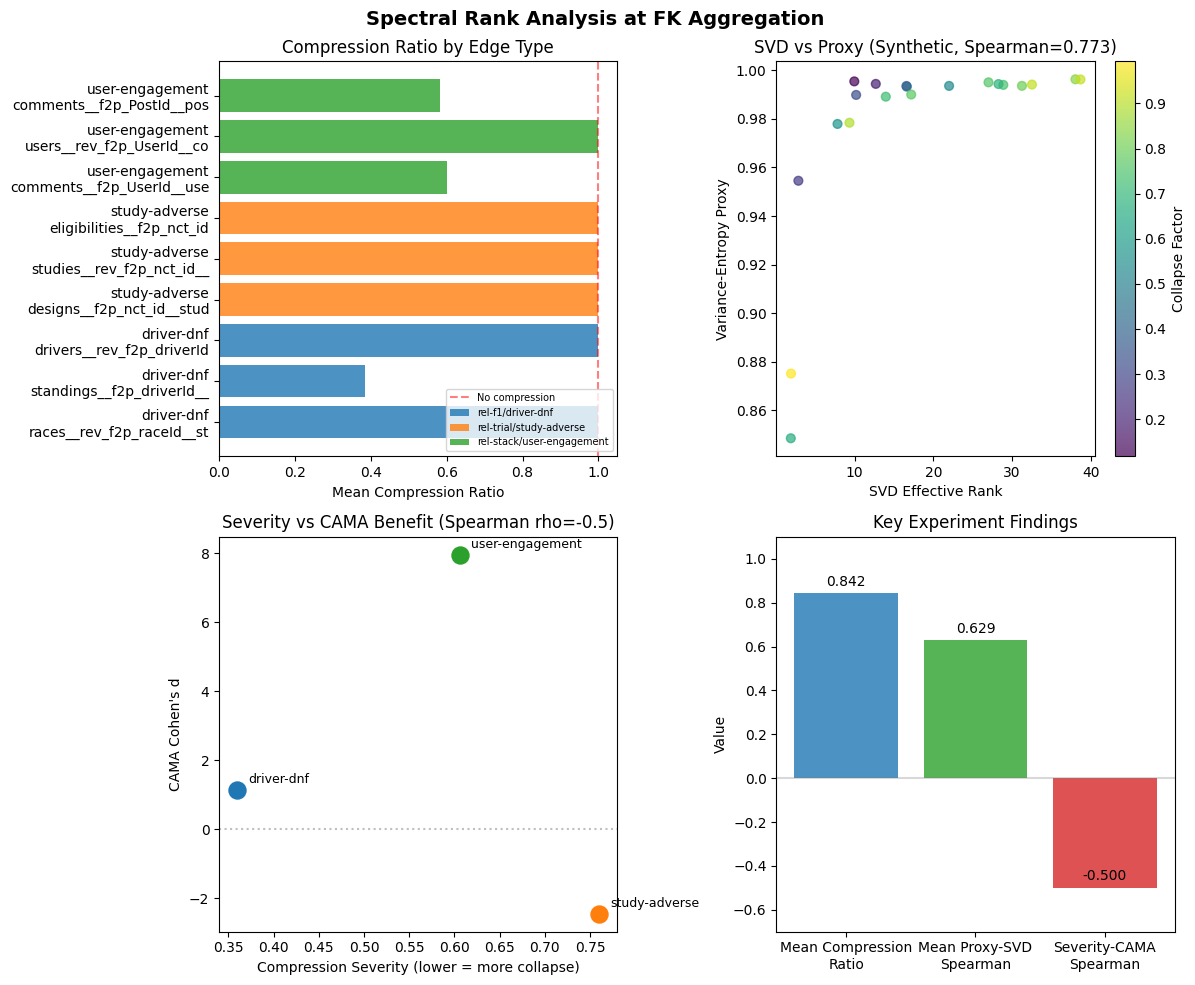


SUMMARY: Spectral Rank Analysis Results
  Rank collapse observed:       True
  Mean compression ratio:       0.8424
  Proxy validates SVD:          True
  Mean proxy-SVD Spearman:      0.6294
  Severity-CAMA Spearman rho:   -0.5
  Disconfirmation triggered:    False


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- Plot 1: Compression ratios by edge type and task ---
ax = axes[0, 0]
tasks = df_edges['task'].unique()
colors = {'rel-f1/driver-dnf': '#1f77b4', 'rel-trial/study-adverse': '#ff7f0e',
          'rel-stack/user-engagement': '#2ca02c'}
for task in tasks:
    subset = df_edges[df_edges['task'] == task]
    short_name = task.split('/')[1]
    ax.barh([f"{short_name}\n{e.split('/')[-1][:25]}" for e in subset['edge_type']],
            subset['mean_compression'], color=colors.get(task, 'gray'), alpha=0.8,
            label=task)
ax.set_xlabel('Mean Compression Ratio')
ax.set_title('Compression Ratio by Edge Type')
ax.axvline(x=1.0, color='red', linestyle='--', alpha=0.5, label='No compression')
ax.legend(fontsize=7, loc='lower right')

# --- Plot 2: SVD rank vs proxy rank (synthetic) ---
ax = axes[0, 1]
sc = ax.scatter(df_synth['svd_effective_rank'], df_synth['proxy_rank'],
                c=df_synth['collapse_factor'], cmap='viridis', alpha=0.7, s=40)
plt.colorbar(sc, ax=ax, label='Collapse Factor')
rho_synth, _ = spearmanr(df_synth['svd_effective_rank'], df_synth['proxy_rank'])
ax.set_xlabel('SVD Effective Rank')
ax.set_ylabel('Variance-Entropy Proxy')
ax.set_title(f'SVD vs Proxy (Synthetic, Spearman={rho_synth:.3f})')

# --- Plot 3: Task severity vs CAMA Cohen's d ---
ax = axes[1, 0]
for _, row in df_cross.iterrows():
    short = row['task'].split('/')[1]
    ax.scatter(row['severity'], row['cama_cohen_d'],
              s=150, color=colors.get(row['task'], 'gray'), zorder=5)
    ax.annotate(short, (row['severity'], row['cama_cohen_d']),
               textcoords='offset points', xytext=(8, 5), fontsize=9)
ax.set_xlabel('Compression Severity (lower = more collapse)')
ax.set_ylabel('CAMA Cohen\'s d')
ax.set_title('Severity vs CAMA Benefit (Spearman rho=-0.5)')
ax.axhline(y=0, color='gray', linestyle=':', alpha=0.5)

# --- Plot 4: Summary statistics ---
ax = axes[1, 1]
findings = data['metadata']['key_findings']
labels = ['Mean Compression\nRatio', 'Mean Proxy-SVD\nSpearman',
          'Severity-CAMA\nSpearman']
values = [
    findings['mean_compression_ratio'],
    findings['mean_proxy_svd_spearman'],
    findings['spearman_severity_vs_d']
]
bar_colors = ['#1f77b4', '#2ca02c', '#d62728']
bars = ax.bar(labels, values, color=bar_colors, alpha=0.8)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Value')
ax.set_title('Key Experiment Findings')
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_ylim(-0.7, 1.1)

plt.suptitle('Spectral Rank Analysis at FK Aggregation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "="*70)
print("SUMMARY: Spectral Rank Analysis Results")
print("="*70)
print(f"  Rank collapse observed:       {findings['rank_collapse_observed']}")
print(f"  Mean compression ratio:       {findings['mean_compression_ratio']:.4f}")
print(f"  Proxy validates SVD:          {findings['proxy_validates_svd']}")
print(f"  Mean proxy-SVD Spearman:      {findings['mean_proxy_svd_spearman']:.4f}")
print(f"  Severity-CAMA Spearman rho:   {findings['spearman_severity_vs_d']}")
print(f"  Disconfirmation triggered:    {findings['disconfirmation_triggered']}")
print("="*70)